In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

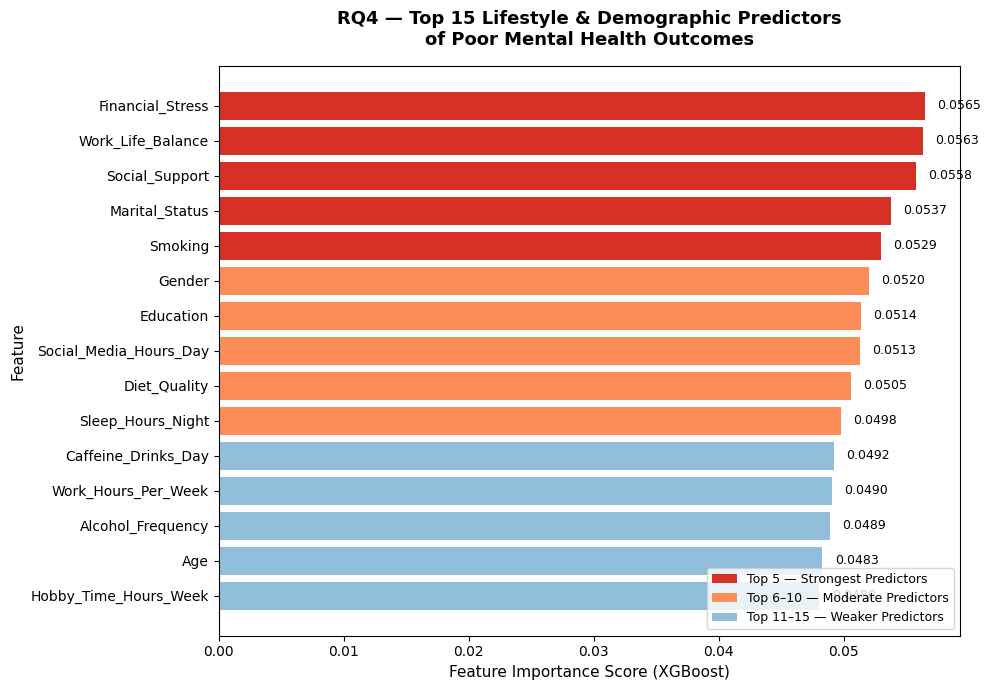

RQ4 — Feature Importance Results
               Feature  Importance
      Financial_Stress    0.056461
     Work_Life_Balance    0.056309
        Social_Support    0.055761
        Marital_Status    0.053743
               Smoking    0.052945
                Gender    0.051997
             Education    0.051358
Social_Media_Hours_Day    0.051285
          Diet_Quality    0.050533
     Sleep_Hours_Night    0.049750
   Caffeine_Drinks_Day    0.049173
   Work_Hours_Per_Week    0.049035
     Alcohol_Frequency    0.048880
                   Age    0.048281
 Hobby_Time_Hours_Week    0.048048
   Close_Friends_Count    0.047238
 Screen_Time_Hours_Day    0.046007
     Exercise_Per_Week    0.045477
     Employment_Status    0.044716
          Income_Level    0.043004

Top 5 Strongest Predictors:
  1. Financial_Stress — 0.0565
  2. Work_Life_Balance — 0.0563
  3. Social_Support — 0.0558
  4. Marital_Status — 0.0537
  5. Smoking — 0.0529
RQ4 Complete! Files saved: RQ4_table.csv, RQ4_figure.pdf


In [1]:
# ============================================================
# RQ4: Which lifestyle and demographic features are the
# strongest predictors of poor mental health outcomes, and
# how can these insights be interpreted for real-world
# interventions?
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# --- Step 1: Load Dataset ---
df = pd.read_csv("/kaggle/input/datasets/dhrubangtalukdar/global-mental-health-and-lifestyle-survey-dataset/mental_health.csv")

# --- Step 2: Encode Categorical Columns ---
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# --- Step 3: Define Lifestyle & Demographic Features ---
rq4_cols = [
    # Demographic
    "Age", "Gender", "Education", "Marital_Status",
    "Income_Level", "Employment_Status",
    # Lifestyle
    "Sleep_Hours_Night", "Exercise_Per_Week",
    "Screen_Time_Hours_Day", "Social_Media_Hours_Day",
    "Caffeine_Drinks_Day", "Alcohol_Frequency",
    "Smoking", "Diet_Quality", "Hobby_Time_Hours_Week",
    "Social_Support", "Close_Friends_Count",
    "Work_Hours_Per_Week", "Work_Life_Balance",
    "Financial_Stress"
]

X = df[rq4_cols]
y = df["Has_Mental_Health_Issue"]

# --- Step 4: Train XGBoost Model ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

# --- Step 5: Extract Feature Importances ---
importance_scores = model.feature_importances_
df_importance = pd.DataFrame({
    "Feature": rq4_cols,
    "Importance": importance_scores
}).sort_values("Importance", ascending=False).reset_index(drop=True)

# --- Step 6: Save Table ---
df_importance.to_csv("RQ4_table.csv", index=False)

# --- Step 7: Plot Top 15 Features ---
top15 = df_importance.head(15)
colors = ['#d73027' if i < 5 else '#fc8d59' if i < 10 else '#91bfdb'
          for i in range(len(top15))]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15["Feature"][::-1], top15["Importance"][::-1], color=colors[::-1])
ax.set_title("RQ4 — Top 15 Lifestyle & Demographic Predictors\nof Poor Mental Health Outcomes", 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Feature Importance Score (XGBoost)", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)

# Add value labels on bars
for bar, val in zip(bars, top15["Importance"][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d73027', label='Top 5 — Strongest Predictors'),
    Patch(facecolor='#fc8d59', label='Top 6–10 — Moderate Predictors'),
    Patch(facecolor='#91bfdb', label='Top 11–15 — Weaker Predictors')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig("RQ4_figure.pdf")
plt.show()

# --- Step 8: Print Results ---
print("=" * 50)
print("RQ4 — Feature Importance Results")
print("=" * 50)
print(df_importance.to_string(index=False))
print("=" * 50)
print("\nTop 5 Strongest Predictors:")
for i, row in df_importance.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']} — {row['Importance']:.4f}")
print("=" * 50)
print("RQ4 Complete! Files saved: RQ4_table.csv, RQ4_figure.pdf")